# Notebook 04 - Coastal Water Mask and Spectral Analysis

## Objective

- This notebook develops a robust coastal water mask from Planet Tanager hyperspectral imagery.

- After isolating water pixels, we investigate the spatial variability of coastal water reflectance to identify regions with differing optical properties that may correspond to sediment-rich water, shallow water, or clearer offshore water.

- The outputs from this notebook form the basis for later clustering and water-quality interpretation.

In [10]:
#1_Import data
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,8)

DATA_PATH = Path(r"C:\GIS_Work\5 GeoSpectra AI\data\raw\20250824_171857_84_4001_ortho_sr_hdf5.h5")


In [11]:
#2_Load data
with h5py.File(DATA_PATH, "r") as f:
    cube = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"][:]
    wavelengths = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["wavelengths"]
    good = f["HDFEOS/GRIDS/HYP/Data Fields/surface_reflectance"].attrs["good_wavelengths"]
    cloud = f["HDFEOS/GRIDS/HYP/Data Fields/beta_cloud_mask"][:]
cube = cube.astype(np.float32)
cube[cube == -9999] = np.nan
print(cube.shape)
print(cloud.shape)

(426, 671, 763)
(671, 763)


In [12]:
#3_Use good bands
cube = cube[good.astype(bool)]
wavelengths = wavelengths[good.astype(bool)]
print(cube.shape)

(368, 671, 763)


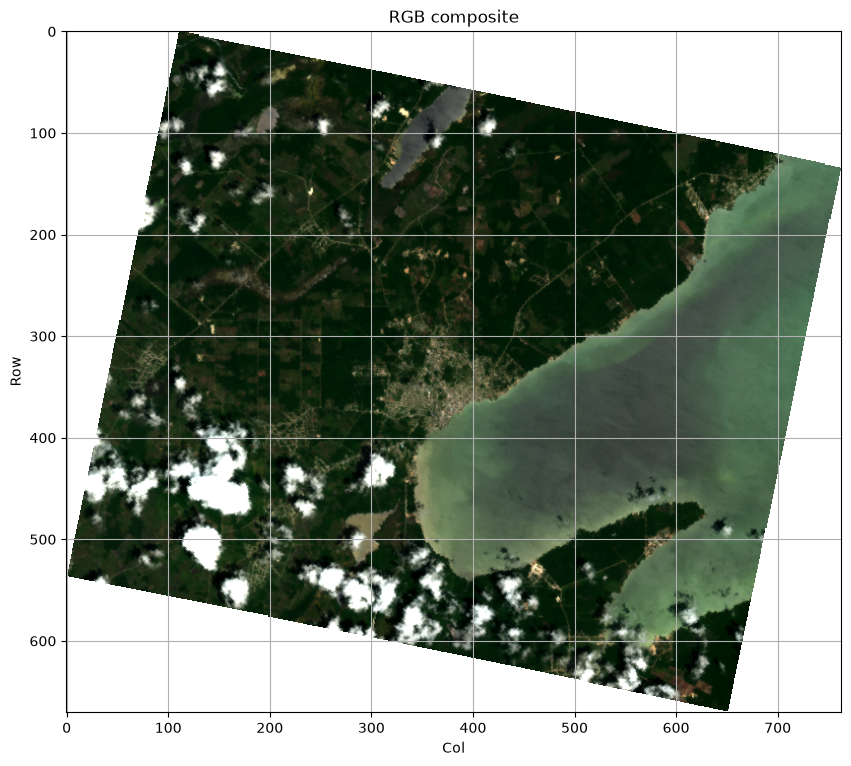

In [13]:
#4_RGB
def find_band(target):
    return np.argmin(np.abs(wavelengths - target))

red = find_band(650)
green = find_band(550)
blue = find_band(470)

def stretch(image, lower=2, upper=98):
    image = image.copy()
    p2 = np.nanpercentile(image, lower)
    p98 = np.nanpercentile(image, upper)
    image = np.clip(image, p2, p98)
    image = (image - p2) / (p98 - p2)
    return image

rgb = np.dstack([cube[red], cube[green], cube[blue]])
rgb = stretch(rgb)

plt.figure(figsize = (10,10))
plt.imshow(rgb)
plt.xlabel("Col")
plt.ylabel("Row")
plt.title("RGB composite")
plt.grid(True)
plt.show()

In [14]:
#5_Find NIR band
def find_band(target):
    return np.argmin(np.abs(wavelengths - target))
nir = find_band(860)
print(wavelengths[nir])
    

861.26


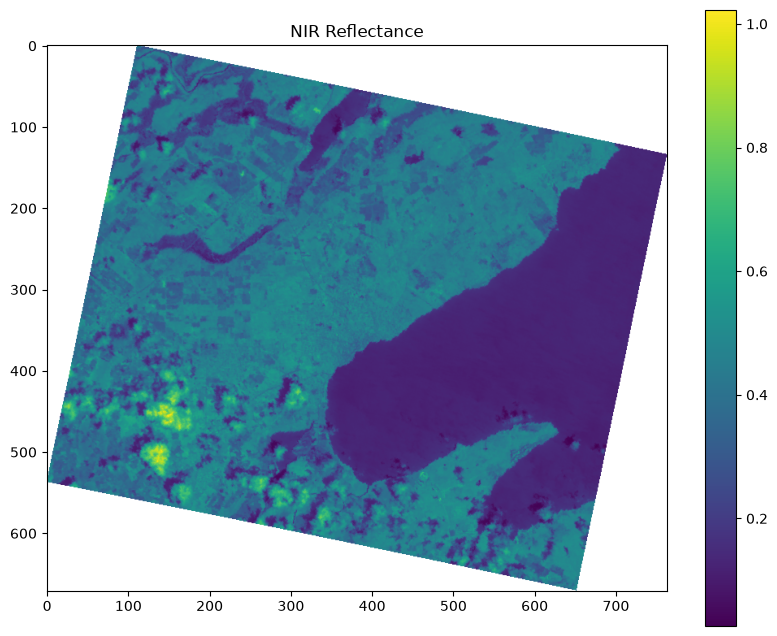

In [15]:
#6_Display NIR
plt.imshow(cube[nir])
plt.colorbar()
plt.title("NIR Reflectance")
plt.show()

In [22]:
#7_NIR Statistics
nir_image = cube[nir]
print("NIR Statistics")
print("------------------------")

print("Minimum :", np.nanmin(nir_image))
print("Maximum :", np.nanmax(nir_image))
print("Mean    :", np.nanmean(nir_image))

print()

for p in [1,5,10,20,30,40,50,60,70,80,90,95,99]:
    print(f"{p:2}% :", np.nanpercentile(nir_image,p))

NIR Statistics
------------------------
Minimum : 0.025935344
Maximum : 1.022488
Mean    : 0.33540305

 1% : 0.11017479
 5% : 0.11975745
10% : 0.1252299
20% : 0.13372527
30% : 0.20673802
40% : 0.3293103
50% : 0.38383666
60% : 0.42149276
70% : 0.44572634
80% : 0.46568993
90% : 0.4903765
95% : 0.5156607
99% : 0.64869714


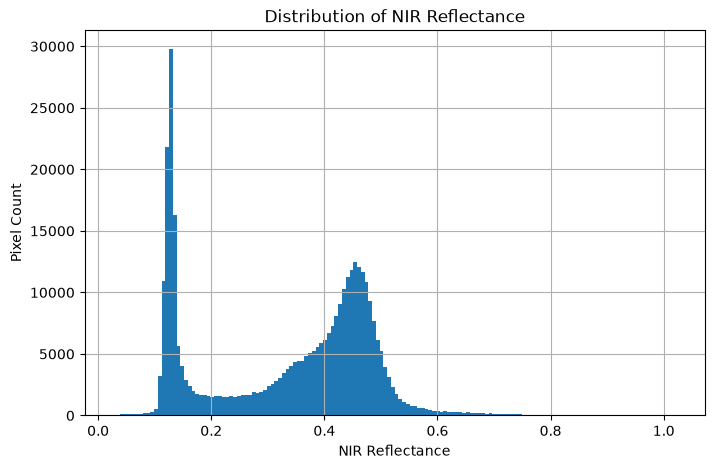

In [23]:
#8_Distribution of NIR
valid = nir_image[~np.isnan(nir_image)]

plt.figure(figsize=(8,5))

plt.hist(valid, bins=150)

plt.xlabel("NIR Reflectance")
plt.ylabel("Pixel Count")
plt.title("Distribution of NIR Reflectance")

plt.grid(True)

plt.show()

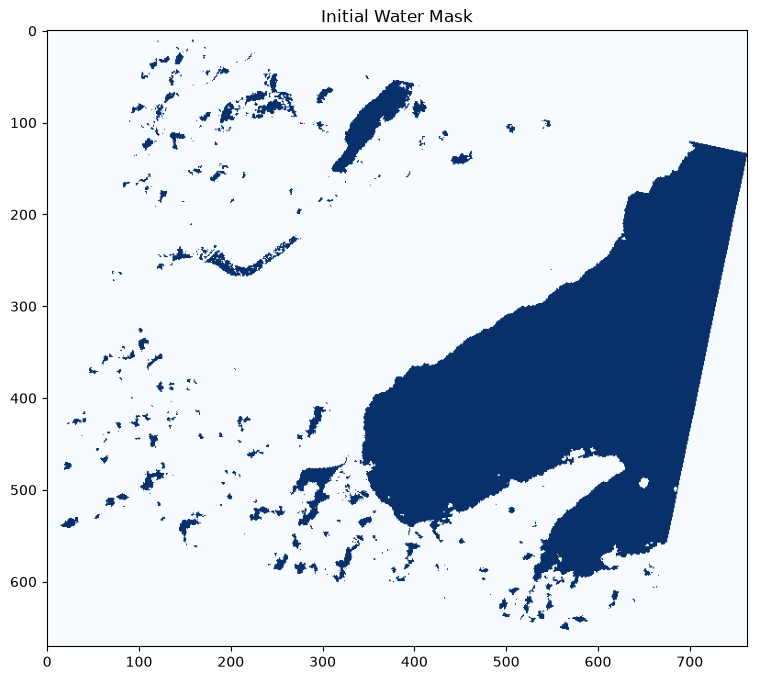

In [34]:
#9_Initial Water Mask
nir_image = cube[nir]

water_mask = nir_image < 0.2

plt.imshow(water_mask, cmap="Blues")
plt.title("Initial Water Mask")
plt.show()

In [35]:
#10_Remove clouds
water_mask = np.logical_and(water_mask, cloud == 0)

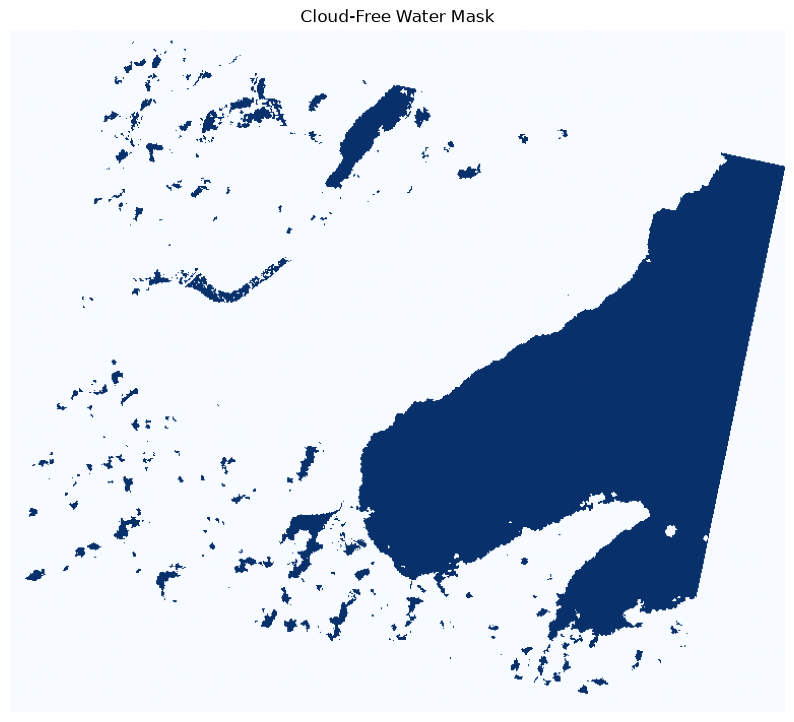

In [36]:
#11_Cloud free mask
plt.figure(figsize=(10,10))

plt.imshow(
    water_mask,
    cmap="Blues"
)

plt.title("Cloud-Free Water Mask")

plt.axis("off")

plt.show()

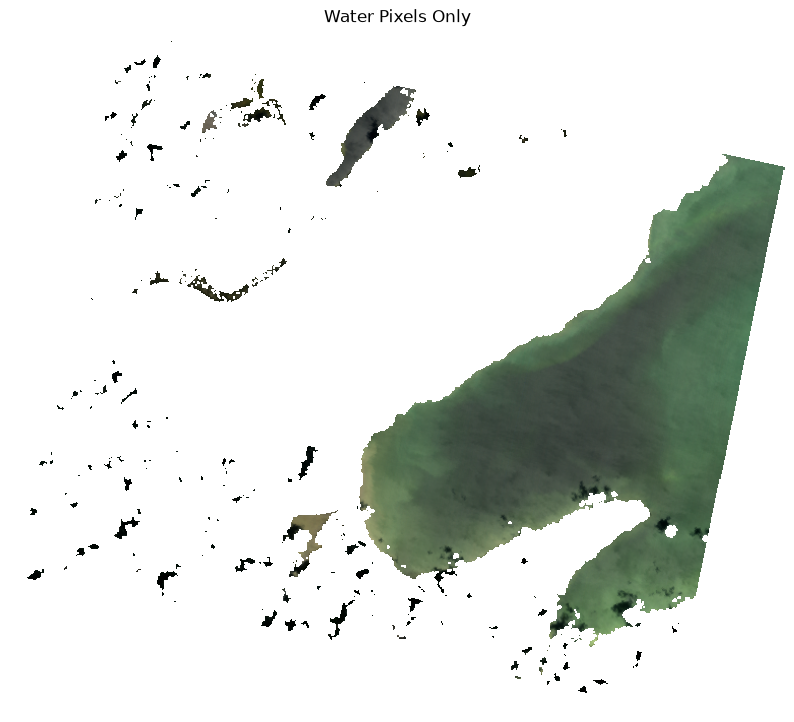

In [42]:
#12_Initial Water-only RGB
rgb_water = rgb.copy()

rgb_water[~water_mask]=np.nan

plt.figure(figsize=(10,10))

plt.imshow(rgb_water)

plt.title("Water Pixels Only")

plt.axis("off")

plt.show()

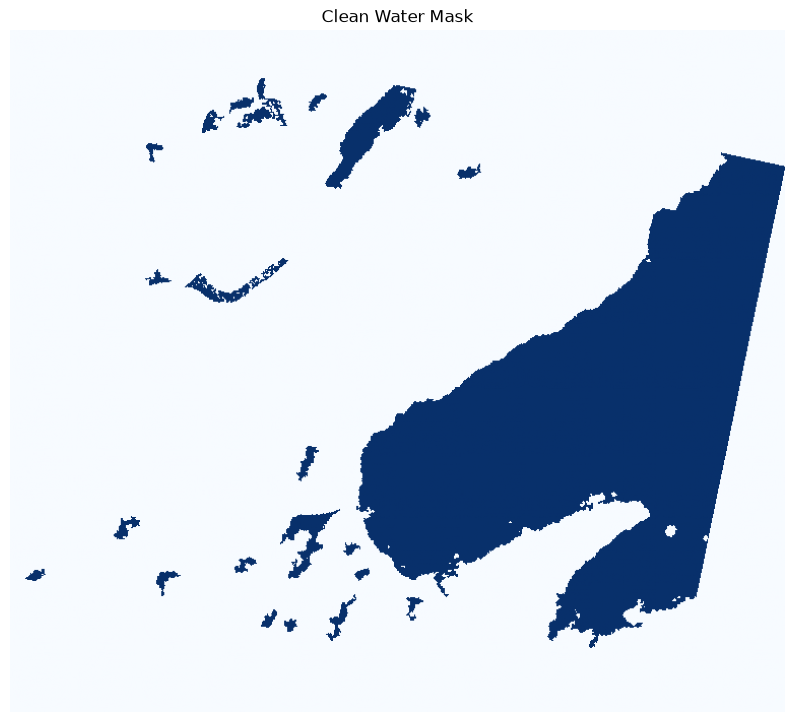

In [43]:
#13_Image cleaning
from scipy import ndimage

# Remove connected components smaller than 100 pixels
labels, num = ndimage.label(water_mask)

sizes = ndimage.sum(water_mask, labels, range(num + 1))

clean_mask = sizes[labels] > 100

plt.figure(figsize=(10,10))
plt.imshow(clean_mask, cmap="Blues")
plt.title("Clean Water Mask")
plt.axis("off")
plt.show()

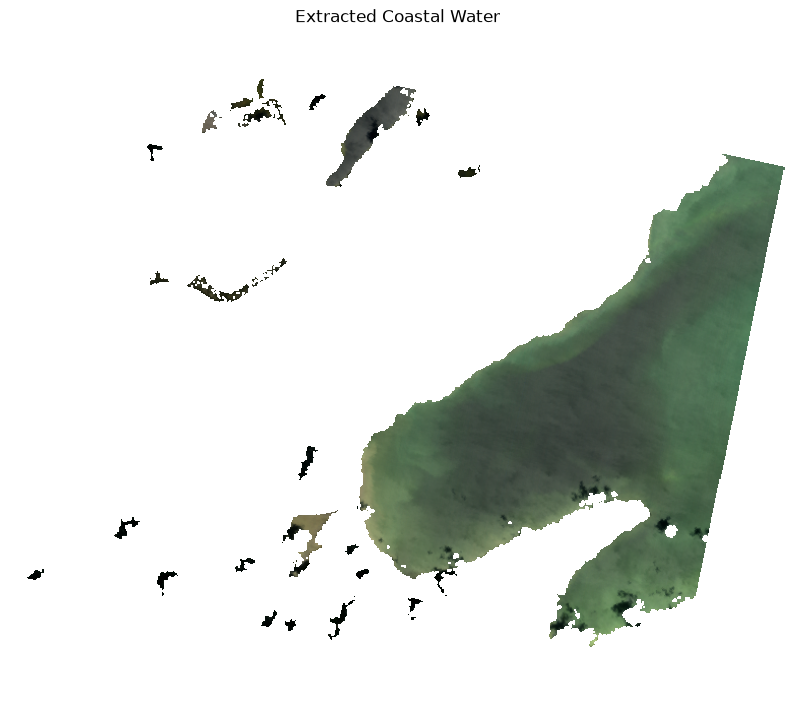

In [49]:
#14_Water-only RGB
rgb_water = rgb.copy()

rgb_water[~clean_mask] = np.nan

plt.figure(figsize=(10,10))
plt.imshow(rgb_water)
plt.title("Extracted Coastal Water")
plt.axis("off")
plt.show()

In [53]:
#15_Water pixel count
water_pixels = np.count_nonzero(clean_mask)
total_pixels = clean_mask.size

print("Water Pixels :", water_pixels)
print("Total Pixels :", total_pixels)
print(f"Water Coverage : {100*water_pixels/total_pixels:.2f}%")

Water Pixels : 103239
Total Pixels : 511973
Water Coverage : 20.16%


In [54]:
#16_Extract water hyperspectral cube

water_cube = cube.copy()

water_cube[:, ~clean_mask] = np.nan

print(water_cube.shape)

(368, 671, 763)


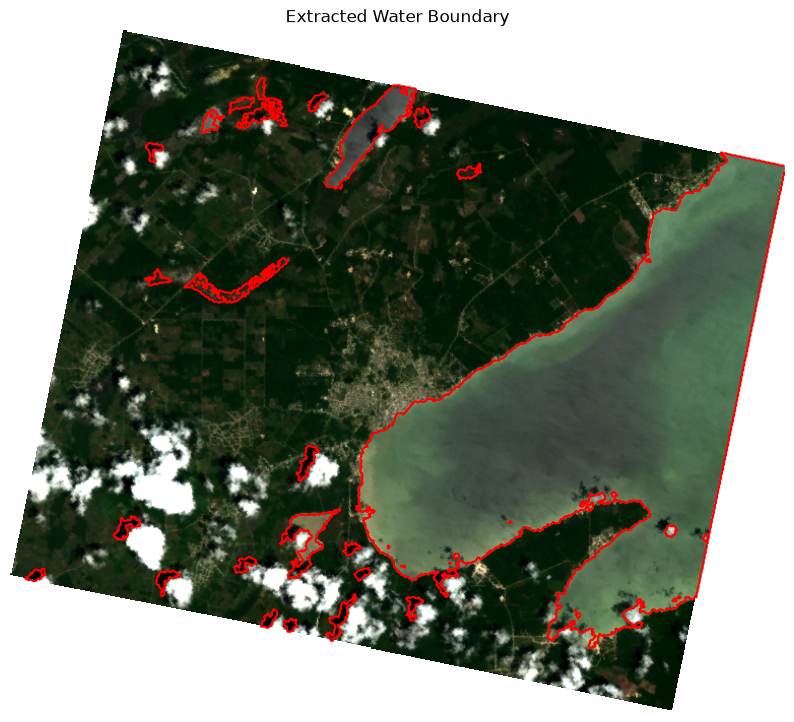

In [55]:
#17_Overlay extracted water on RGB
plt.figure(figsize=(10,10))

plt.imshow(rgb)

plt.contour(clean_mask, levels=[0.5], colors="red", linewidth=1.5)

plt.title("Extracted Water Boundary")

plt.axis("off")

plt.show()

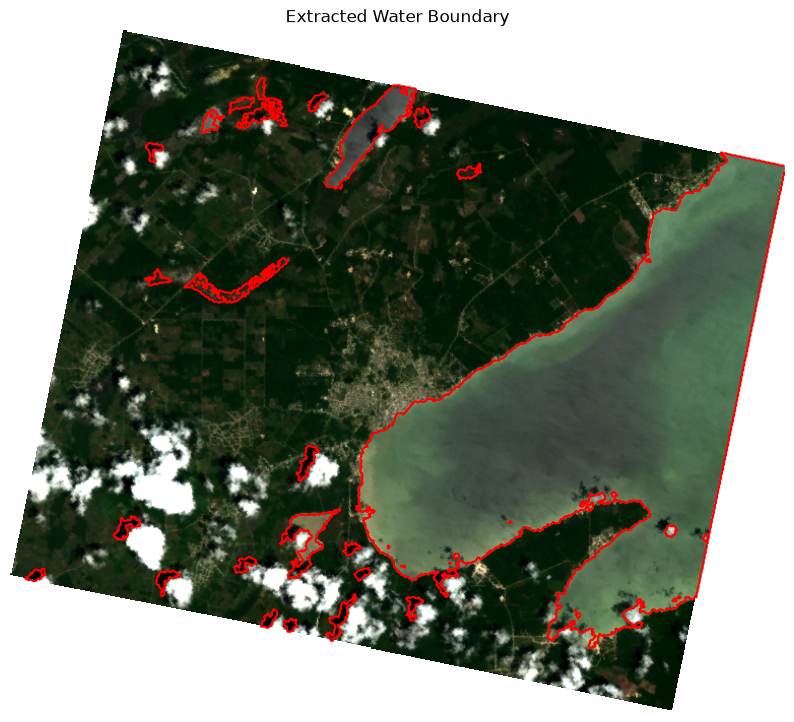

Outputs successfully saved.


In [65]:
#18_Save outputs

from pathlib import Path

output_dir = Path(r"C:\GIS_Work\5 GeoSpectra AI\outputs\maps")

output_dir.mkdir(exist_ok=True)

np.save(output_dir/"water_mask.npy", clean_mask)

np.save(output_dir/"water_cube.npy", water_cube)

#Save binary mask
plt.imsave(output_dir/"water_mask.png", clean_mask, cmap="Blues")

#Save RGB water image
plt.imsave(output_dir/"rgb_water.png", rgb_water)

#Save boundary overlay
plt.figure(figsize=(10,10))

plt.imshow(rgb)

plt.contour(clean_mask, levels=[0.5], colors="red", linewidth=1.5)

plt.title("Extracted Water Boundary")
plt.axis("off")

plt.savefig(output_dir / "water_boundary_overlay.png", dpi=300, bbox_inches="tight")

plt.show()

print("Outputs successfully saved.")